In [43]:
import nilearn
from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import MultiNiftiLabelsMasker
import os
import requests
import csv
import pandas as pd
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import scipy
from scipy.stats import multivariate_normal
from scipy.spatial.distance import pdist, squareform
from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics.cluster import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.sparse.csgraph import minimum_spanning_tree
from collections import deque, defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

In [44]:
import torch
device = torch.device("gpu" if torch.cuda.is_available() else "cpu")

In [51]:
home_base_dir = '/Users/aj/dmello_lab/fmri_connectivity_trees' # directory where repository lives at home computer
lab_base_dir = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees' # directory where repository lives at lab computer

# set base directory depending on where the code is being run
base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir

# get msdl and whole brain atlases and coords
# `msdl_data = datasets.fetch_atlas_msdl()
# msdl_coords = msdl_data.region_coords`

# get schaefer
# schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7, resolution_mm=1, data_dir=None, base_url=None, resume=True, verbose=1)
# schaefer_coords = plotting.find_parcellation_cut_coords(labels_img=schaefer.maps)

# get suit
suit_labels = pd.read_csv(f'{base_dir}/atlases/suit/atl-Anatom.tsv', sep='\t')

# get glasser labels
file_path = f'{base_dir}/atlases/glasser360/glasser360NodeNames.txt'
with open(file_path, 'r') as file:
    glasser_labels = file.readlines()

# concatenate timeseries to get a single timeseries for each subject
def get_timeseries(ids, cort_shape_path, cort_pooled_path):
    timeseries = []
    for id in ids:

        # load the shape and pooled timeseries
        shape = np.loadtxt(f'{cort_shape_path}/{id}.csv', delimiter=',').astype(int)
        pooled = np.loadtxt(f'{cort_pooled_path}/{id}.csv', delimiter=',').reshape(shape)

        # concatenate the timeseries
        timeseries.append(pooled)

    return timeseries

# path for shapes and pooled timeseries
subjects = [
            'MSC01',
            'MSC02', 
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]
sessions = ['func01', 'func02', 'func03', 'func04', 'func05', 'func06', 'func07', 'func08', 'func09', 'func10']
ids = ['rest']

atlas_subdir = "glasser360"

atlas = 'glasser360'

cort_timeseries = {}
for subject in subjects:
    cort_shape_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/func01/{atlas}/all_tasks/shape/'
    cort_pooled_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/func01/{atlas}/all_tasks/pooled/'
    cort_timeseries[subject] = get_timeseries(ids, cort_shape_path, cort_pooled_path)
    for session in sessions[1:]:
        cort_shape_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/{session}/{atlas}/all_tasks/shape/'
        cort_pooled_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/{session}/{atlas}/all_tasks/pooled/'
        cort_timeseries[subject] = cort_timeseries[subject] + get_timeseries(ids, cort_shape_path, cort_pooled_path)

cereb_timeseries = {}
atlas = 'SUIT'
for subject in subjects:
    cereb_shape_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/func01/{atlas}/all_tasks/shape/'
    cereb_pooled_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/func01/{atlas}/all_tasks/pooled/'
    cereb_timeseries[subject] = get_timeseries(ids, cereb_shape_path, cereb_pooled_path)
    for session in sessions[1:]:
        cereb_shape_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/{session}/{atlas}/all_tasks/shape/'
        cereb_pooled_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/roi_time_series/{subject}/{session}/{atlas}/all_tasks/pooled/'
        cereb_timeseries[subject] = cereb_timeseries[subject] + get_timeseries(ids, cereb_shape_path, cereb_pooled_path)

In [52]:
def get_concat(timeseries, use_torch=True):
    """
    Concatenate the timeseries for each subject.
    """
    concat_timeseries = {}
    for subject, ts in timeseries.items():
        concat_timeseries[subject] = np.concatenate(ts, axis=0).T
    if use_torch:
        for subject in concat_timeseries:
            concat_timeseries[subject] = torch.tensor(np.float32(concat_timeseries[subject]), device=device)
    return concat_timeseries

def combine_cort_and_cereb(cort_concat_timeseries, cereb_concat_timeseries, use_torch=True):
    
    timeseries = {}
    for subject in cort_concat_timeseries:
        timeseries[subject] = np.concatenate((cort_concat_timeseries[subject].cpu().numpy(), cereb_concat_timeseries[subject].cpu().numpy()), axis=0)
    if use_torch:
        for subject in timeseries:
            timeseries[subject] = torch.tensor(np.float32(timeseries[subject]), device=device)
    return timeseries

def discretize_time_series(timeseries, num_bins=10):
    """
    Discretize the time series data into specified number of bins using matrix operations.
    """
    timeseries = timeseries.contiguous()  # Ensure the tensor is contiguous for efficient operations
    bin_edges = torch.linspace(timeseries.min(), timeseries.max(), steps=num_bins + 1, device=timeseries.device)[1:-1]
    discretized = torch.bucketize(timeseries, bin_edges)
    return discretized

def joint_prob(a, b, discretized_timeseries, num_bins=10):
    """
    Compute the joint probability matrix for two ROIs a and b using matrix operations.
    """
    a = discretized_timeseries[a, :]
    b = discretized_timeseries[b, :]
    joint_indices = num_bins * a + b
    joint_prob_mat = torch.bincount(joint_indices, minlength=num_bins * num_bins).reshape(num_bins, num_bins).float()
    joint_prob_mat /= joint_prob_mat.sum()  # Normalize to get probabilities
    return joint_prob_mat

def get_joint_probs(discretized_timeseries, num_bins=10):
    """
    Compute the joint probability matrices for all pairs of ROIs using matrix operations.
    """
    num_rois = discretized_timeseries.shape[0]
    joint_probs = torch.zeros((num_rois, num_rois, num_bins, num_bins), dtype=torch.float32, device=discretized_timeseries.device)
    for i in range(num_rois):
        for j in range(num_rois):
            if i != j:
                joint_probs[i, j] = joint_prob(i, j, discretized_timeseries, num_bins)
    return joint_probs

def marginal_prods(a, b, joint_probs, num_bins=10):
    """
    Compute the product of marginals for two ROIs a and b using matrix operations.
    Element (i, j) is P(a=i) * P(b=j).
    """
    joint_prob_mat = joint_probs[a, b]
    marginal_a = joint_prob_mat.sum(axis=1)  # P(a=i)
    marginal_b = joint_prob_mat.sum(axis=0)  # P(b=j)
    return torch.outer(marginal_a, marginal_b)  # Element (i, j) = P(a=i) * P(b=j)

def get_product_of_marginals(joint_probs, num_bins=10):
    """
    Compute the product of marginals for all pairs of ROIs using matrix operations.
    """
    num_rois = joint_probs.shape[0]
    product_marginals = torch.zeros((num_rois, num_rois, num_bins, num_bins), dtype=torch.float32, device=joint_probs.device)
    for i in range(num_rois):
        for j in range(num_rois):
            if i != j:
                product_marginals[i, j] = marginal_prods(i, j, joint_probs, num_bins)
    return product_marginals

def mutual_information(a, b, joint_probs, product_marginals, num_bins=10):
    """
    Compute the mutual information between two ROIs a and b.
    """
    joint_prob_mat = joint_probs[a, b]
    product_marginal_mat = product_marginals[a, b]

    # Avoid division by zero
    joint_prob_mat[joint_prob_mat == 0] = 1e-10
    product_marginal_mat[product_marginal_mat == 0] = 1e-10

    # Compute mutual information
    mi = torch.sum(joint_prob_mat * torch.log(joint_prob_mat / product_marginal_mat))

    return mi

def get_mutual_information(joint_probs, product_marginals, num_bins=10):
    """
    Compute the mutual information matrix for all pairs of ROIs using matrix operations.
    """
    num_rois = joint_probs.shape[0]
    mi_matrix = torch.zeros((num_rois, num_rois), dtype=torch.float32, device=joint_probs.device)
    # Compute mutual information for each pair of ROIs
    for i in range(num_rois):
        for j in range(num_rois):
            if i != j:
                mi_matrix[i, j] = mutual_information(i, j, joint_probs, product_marginals, num_bins)
    return mi_matrix

def pairwise_roi_mutual_information(timeseries, num_bins=10):
    """
    Compute the pairwise mutual information matrix for the given time series data.
    This function discretizes the time series data, computes joint probabilities,
    computes the product of marginals, and then calculates the mutual information matrix.
    """
    discretized_timeseries = discretize_time_series(timeseries, num_bins=num_bins)
    joint_probs = get_joint_probs(discretized_timeseries, num_bins=num_bins)
    product_marginals = get_product_of_marginals(joint_probs, num_bins=num_bins)
    mi_matrix = get_mutual_information(joint_probs, product_marginals, num_bins=num_bins)
    return mi_matrix, joint_probs, product_marginals

def save_data(data, subject, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=10):
    """
    Save the covariance matrix to a CSV file.
    """
    output_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
    if skl:
        task = f'{task}_skl_{num_bins}bins'
    else:
        task = f'{task}_{num_bins}bins'
    os.makedirs(output_path, exist_ok=True)
    np.save(f'{output_path}/{task}.npy', data.cpu())

def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=10):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'

        data[subject] = np.load(f'{data_path}/{file_name}.npy')
    return data

def plot_connectome(cov_matrix, coords, title='connectome', edge_threshold="0%", edge_vmin=0, edge_vmax=1):
    """
    Plot the connectome using the mean correlation matrix and coordinates.
    """
    # Plotting the connectome
    plotting.plot_connectome(
        cov_matrix,
        coords,
        title=title,
        edge_vmin = edge_vmin,
        edge_vmax = edge_vmax,
        edge_cmap='cold_hot',
        edge_threshold=edge_threshold,  # Only plot edges above the 90th percentile
        colorbar=True,
        node_size=10,
    )
    plt.show()

## **toy testing**

In [8]:
# testing toy data
joint_toy = torch.tensor([[[[0.1, 0.2], [0.3, 0.4]]]])
marginal_prods(0, 0, joint_toy, num_bins=2)

tensor([[0.1200, 0.1800],
        [0.2800, 0.4200]])

In [14]:
a = torch.tensor([0, 1, 2, 3])
b = torch.tensor([1, 1, 1, 1])
num_bins = 4
joint_indices = num_bins * a + b
joint_prob_mat = torch.bincount(joint_indices, minlength=num_bins * num_bins).reshape(num_bins, num_bins).float()
joint_prob_mat /= joint_prob_mat.sum()  # Normalize to get probabilities
joint_prob_mat

tensor([[0.0000, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000]])

In [17]:
marginal_a = joint_prob_mat.sum(axis=1)  # P(a=i)
marginal_b = joint_prob_mat.sum(axis=0)  # P(b=j)
torch.outer(marginal_a, marginal_b)  # Element (i, j) = P(a=i) * P(b=j)

tensor([[0.0000, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000]])

## **playground**

In [53]:
cort_concat_timeseries = get_concat(cort_timeseries)
cort_concat_timeseries['MSC04'].shape

torch.Size([360, 8180])

In [54]:
cereb_concat_timeseries = get_concat(cereb_timeseries)
cereb_concat_timeseries['MSC04'].shape

torch.Size([32, 8180])

In [55]:
concat_timeseries = combine_cort_and_cereb(cort_concat_timeseries, cereb_concat_timeseries)
concat_timeseries['MSC04'].shape

torch.Size([392, 8180])

In [61]:
atlas_subdir = "glasser_suit"
atlas = 'glasser_suit'
for subject in subjects:
    mi, joint_probs, product_of_marginals = pairwise_roi_mutual_information(concat_timeseries[subject], num_bins=100)
    save_data(mi, subject=subject, task='rest', atlas=atlas, num_bins=100, atlas_subdir=atlas_subdir)
    save_data(joint_probs, subject=subject, measure='joint_probs', task='rest', atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)
    save_data(product_of_marginals, subject=subject, measure='product_of_marginals', task='rest', atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)

OSError: 1536640000 requested and 1073741824 written

In [26]:
max(joint_probs[0][1].flatten())

tensor(0.0071)

In [10]:
mi, joint_probs, product_of_marginals = pairwise_roi_mutual_information(concat_timeseries['MSC03'], num_bins=100)
save_data(mi, subject='MSC03', task='rest', atlas=atlas, num_bins=100, atlas_subdir=atlas_subdir)
save_data(joint_probs, subject='MSC03', measure='joint_probs', task='rest', atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)
save_data(product_of_marginals, subject='MSC03', measure='product_of_marginals', task='rest', atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)

In [11]:
mi = load_data(subjects, num_bins=100)

In [16]:
max(joint_probs[0][1].flatten())

tensor(0.0054)

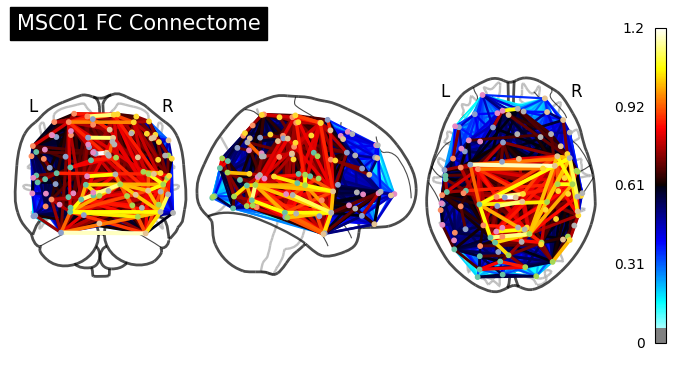

In [12]:
plot_connectome(mi['MSC01'], schaefer_coords, title='MSC01 FC Connectome', edge_threshold="0%", edge_vmax=max(mi['MSC01'].flatten()), edge_vmin=min(mi['MSC01'].flatten()))

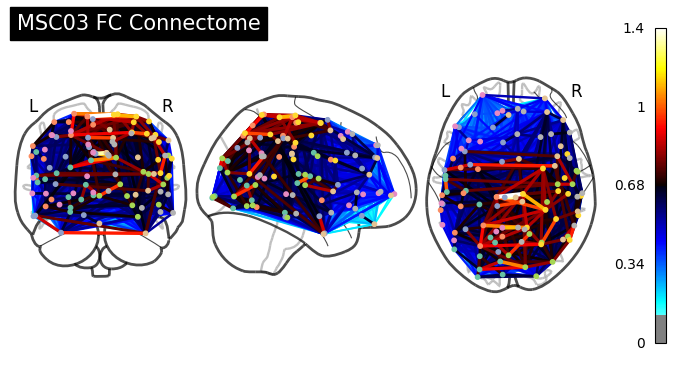

In [13]:
plot_connectome(mi['MSC03'], schaefer_coords, title='MSC03 FC Connectome', edge_threshold="0%", edge_vmax=max(mi['MSC03'].flatten()), edge_vmin=min(mi['MSC03'].flatten()))